# Task 7 - Explainable AI Analysis

## 7.1 Import SHAP

The Voting Ensemble, which was the best model in Task 6, is used in the AI prototype but does not support fast, exact SHAP computation. Therefore, Logistic Regression, the second-best model and one of the ensemble's base estimators, is used as an interpretable proxy. LinearExplainer can efficiently provide exact SHAP values for Logistic Regression.

In [ ]:
!pip install shap -q
import shap
shap.initjs()

## 7.2 Build Explainer and Compute SHAP Values

In [ ]:
explain_model = trained_models['Logistic Regression']

# LinearExplainer is exact and fast for linear models like Logistic Regression
background = shap.sample(X_train_processed, 100, random_state=42)
explainer = shap.LinearExplainer(explain_model, background)
shap_values = explainer.shap_values(X_test_processed)

class_labels = list(target_encoder.classes_)
print("Classes:", class_labels)

Classes: ['High', 'Low', 'Medium']


## 7.3 Global Explanation – Summary Plot

This bar chart compares average feature importance across all three risk classes.

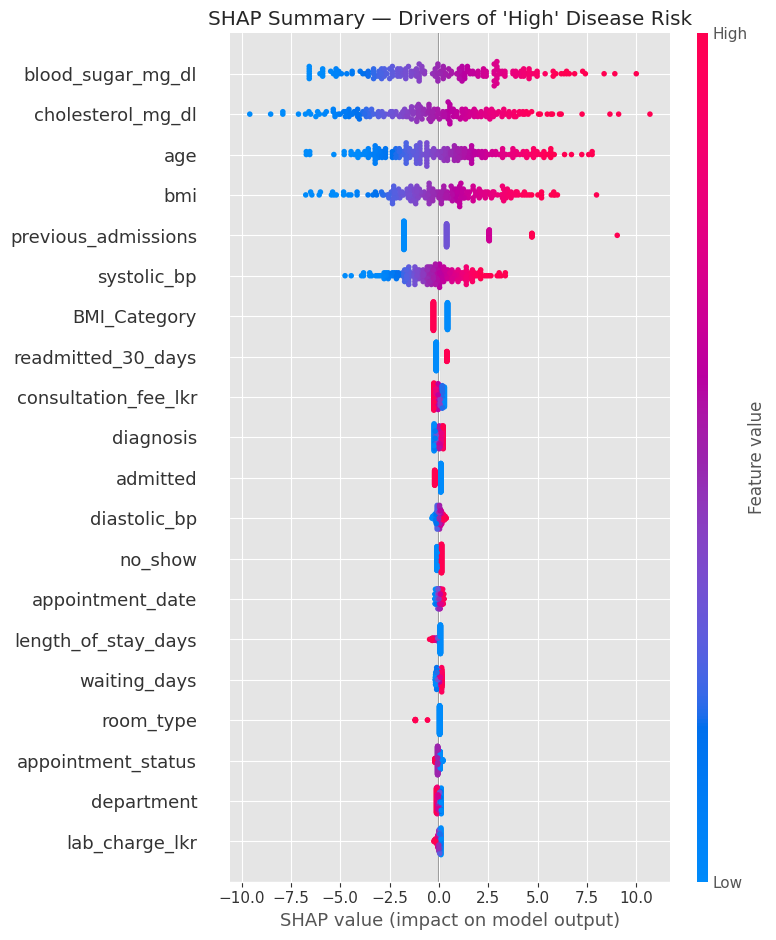

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.summary_plot(shap_values[:, :, high_idx], X_test_processed, feature_names=X.columns, show=False)
plt.title("SHAP Summary — Drivers of 'High' Disease Risk")
plt.tight_layout()
plt.show()

## 7.4 Global Explanation – Feature Importance Across Classes

Waterfall plots below explain individual predictions: a correctly predicted High-risk patient, a correctly predicted Low-risk patient, and a misclassified case.

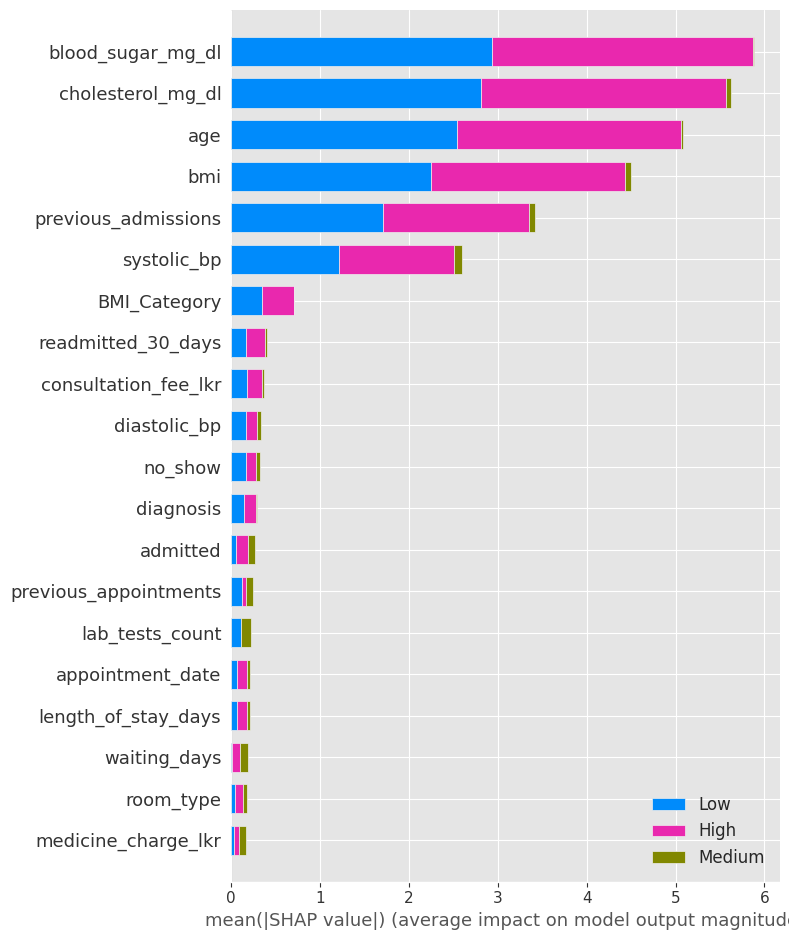

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test_processed, feature_names=X.columns,
                   class_names=class_labels, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## 7.5 Local Explanations - Individual Predictions


Correctly predicted High — predicted: High, actual: High


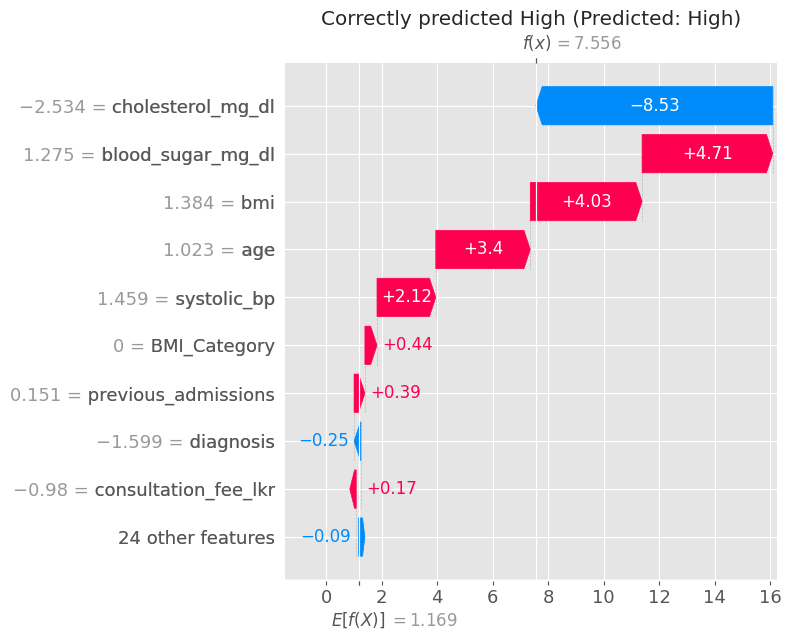


Correctly predicted Low — predicted: Low, actual: Low


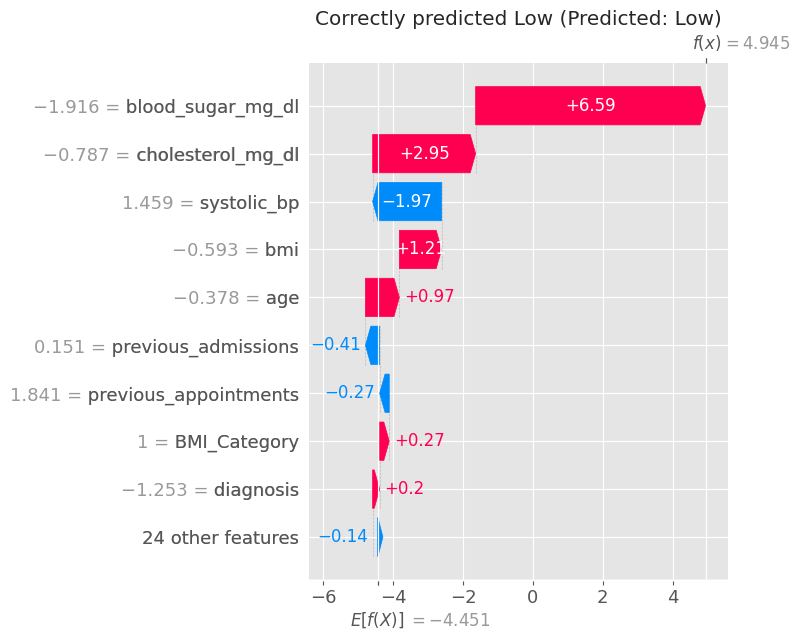


Misclassified case — predicted: Medium, actual: High


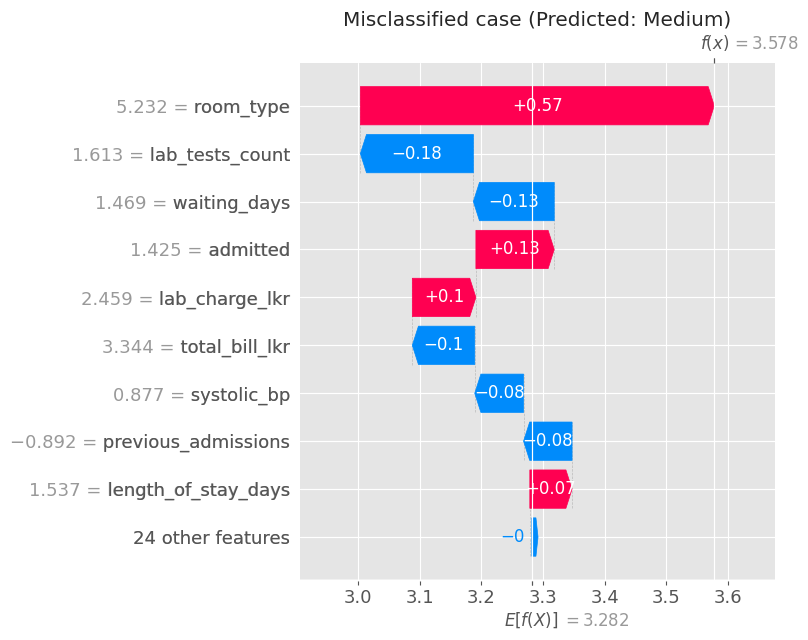

In [ ]:
y_pred_lr = predictions['Logistic Regression']
y_test_arr = y_test_encoded.values if hasattr(y_test_encoded, 'values') else y_test_encoded

correct_high_idx = np.where((y_test_arr == class_labels.index('High')) & (y_pred_lr == class_labels.index('High')))[0][0]
correct_low_idx  = np.where((y_test_arr == class_labels.index('Low'))  & (y_pred_lr == class_labels.index('Low')))[0][0]
misclassified = np.where(y_test_arr != y_pred_lr)[0]
wrong_idx = misclassified[0] if len(misclassified) else correct_high_idx

for label, idx in [("Correctly predicted High", correct_high_idx),
                    ("Correctly predicted Low", correct_low_idx),
                    ("Misclassified case", wrong_idx)]:
    predicted_class = y_pred_lr[idx]
    print(f"\n{label} — predicted: {class_labels[predicted_class]}, actual: {class_labels[y_test_arr[idx]]}")
    explanation = shap.Explanation(
        values=shap_values[idx, :, predicted_class],
        base_values=explainer.expected_value[predicted_class],
        data=X_test_processed.iloc[idx],
        feature_names=X.columns.tolist()
    )
    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"{label} (Predicted: {class_labels[predicted_class]})")
    plt.tight_layout()
    plt.show()

## 7.6 SHAP Dependence Plots - Feature Interaction Effects

<Figure size 640x480 with 0 Axes>

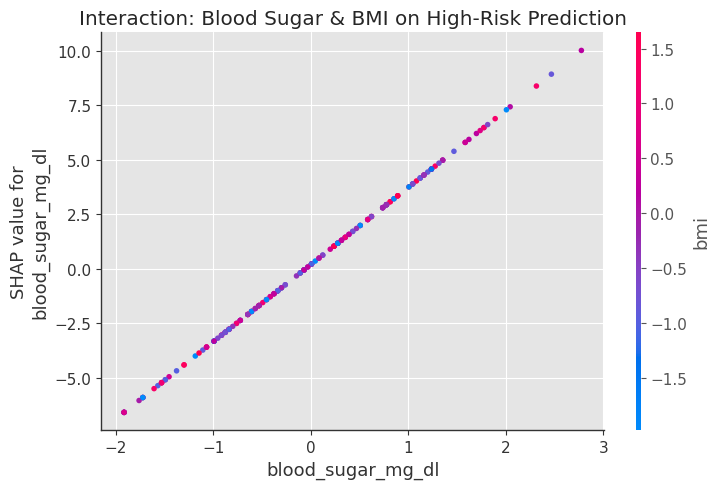

<Figure size 640x480 with 0 Axes>

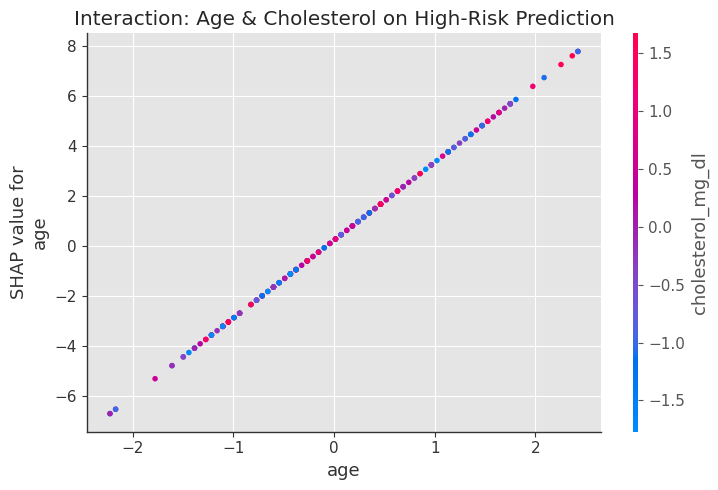

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.dependence_plot(
    "blood_sugar_mg_dl", shap_values[:, :, high_idx], X_test_processed,
    feature_names=X.columns.tolist(), interaction_index="bmi", show=False
)
plt.title("Interaction: Blood Sugar & BMI on High-Risk Prediction")
plt.tight_layout()
plt.show()

plt.figure()
shap.dependence_plot(
    "age", shap_values[:, :, high_idx], X_test_processed,
    feature_names=X.columns.tolist(), interaction_index="cholesterol_mg_dl", show=False
)
plt.title("Interaction: Age & Cholesterol on High-Risk Prediction")
plt.tight_layout()
plt.show()

## 7.7 LIME - Cross-Validation of SHAP Explanations

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed.values,
    feature_names=X.columns.tolist(),
    class_names=class_labels,
    mode='classification',
    random_state=42
)

explain_model = trained_models['Logistic Regression']
lime_exp = lime_explainer.explain_instance(
    X_test_processed.iloc[wrong_idx].values,
    explain_model.predict_proba,
    num_features=10,
    top_labels=1
)
lime_exp.show_in_notebook(show_table=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Interpretation and Ethical Implications

SHAP and LIME show some agreement for the same misclassified case, with both identifying room_type, waiting_days, admitted, and previous_admissions as influential features. However, LIME gives more importance to clinical features such as BMI, systolic blood pressure, and blood sugar, while SHAP is more influenced by operational and billing-related features. This difference suggests that the misclassification may be influenced more by hospital-operations data than by the patient's clinical profile. The SHAP dependence plots also show mostly linear relationships, which is expected for the Logistic Regression model.

# Task 08 - AI Prototype Development



## 8.1 Save the model artifacts

In [ ]:
import joblib

joblib.dump(best_model, 'disease_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

!cp disease_risk_model.pkl scaler.pkl encoders.pkl target_encoder.pkl feature_columns.pkl /content/drive/MyDrive/SmartCare/